In [2]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
df = pd.read_parquet("/content/drive/MyDrive/amazon_reviews_clean.parquet")
print(df.shape)

Mounted at /content/drive
(74545, 9)


In [3]:
!pip install -q bertopic

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.7/154.7 kB 7.6 MB/s eta 0:00:00


In [4]:
negative_reviews = df[df['sentiment'] == 'negative'].copy()
print("Negative reviews:", negative_reviews.shape)
print(negative_reviews['category'].value_counts())

Negative reviews: (9581, 9)
category
Software                    3704
Electronics                 2153
Beauty_and_Personal_Care    2024
Home_and_Kitchen            1700
Name: count, dtype: int64


In [5]:
from bertopic import BERTopic

topic_model = BERTopic(
    language="english",
    min_topic_size=30,
    verbose=True
)

topics, probs = topic_model.fit_transform(negative_reviews['clean_text'].tolist())
negative_reviews['topic'] = topics

print("Number of topics found:", len(set(topics)))

2026-07-29 09:02:19,947 - BERTopic - Embedding - Transforming documents to embeddings.


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/300 [00:00<?, ?it/s]

2026-07-29 09:02:35,169 - BERTopic - Embedding - Completed ✓
2026-07-29 09:02:35,170 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-07-29 09:03:14,996 - BERTopic - Dimensionality - Completed ✓
2026-07-29 09:03:14,998 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-07-29 09:03:15,394 - BERTopic - Cluster - Completed ✓
2026-07-29 09:03:15,403 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-07-29 09:03:15,834 - BERTopic - Representation - Completed ✓


Number of topics found: 48


In [6]:
topic_info = topic_model.get_topic_info()
print(topic_info.head(20))

    Topic  Count                            Name  \
0      -1   2591                -1_the_to_and_it   
1       0    630             0_game_play_you_fun   
2       1    566          1_skin_this_face_smell   
3       2    495               2_app_tv_watch_to   
4       3    432   3_to_windows_software_program   
5       4    394             4_the_coffee_to_and   
6       5    376                5_app_to_this_it   
7       6    318           6_work_product_it_not   
8       7    291                 7_the_was_in_it   
9       8    266      8_sound_headphones_the_ear   
10      9    265            9_kindle_fire_on_app   
11     10    263  10_hair_my_conditioner_shampoo   
12     11    213   11_charge_cable_cord_charging   
13     12    147        12_case_cover_screen_the   
14     13    123        13_camera_the_cameras_to   
15     14    116      14_ads_commercials_ad_many   
16     15    112       15_polish_nail_nails_coat   
17     16    109   16_pillow_mattress_sheets_bed   
18     17   

In [7]:
topic_names = {
    -1: "Uncategorized/Outliers",
    0: "Games - engagement/monetization complaints",
    1: "Skincare - scent/skin reaction issues",
    2: "Streaming apps (Fire TV) - playback issues",
    3: "Software/Windows compatibility issues",
    4: "Coffee product complaints",
    5: "App functionality issues",
    6: "General product not working/returns",
    7: "Furniture/assembly quality issues",
    8: "Headphones - sound quality/ear fit",
    9: "Kindle Fire app/device issues",
    10: "Hair care - conditioner/shampoo issues",
    11: "Charging cables/cords issues",
    12: "Phone/tablet cases and screen covers",
    13: "Camera quality issues",
    14: "Excessive ads/commercials complaints",
    15: "Nail polish quality issues",
    16: "Bedding (pillows/mattress/sheets) issues",
    17: "Razors/hair removal tools issues",
    18: "Product color mismatch issues"
}

negative_reviews['topic_name'] = negative_reviews['topic'].map(topic_names)
print(negative_reviews[['topic', 'topic_name']].drop_duplicates().sort_values('topic'))

       topic                                  topic_name
1         -1                      Uncategorized/Outliers
7800       0  Games - engagement/monetization complaints
385        1       Skincare - scent/skin reaction issues
409        2  Streaming apps (Fire TV) - playback issues
344        3       Software/Windows compatibility issues
11577      4                   Coffee product complaints
296        5                    App functionality issues
46         6         General product not working/returns
361        7           Furniture/assembly quality issues
68         8          Headphones - sound quality/ear fit
698        9               Kindle Fire app/device issues
18960     10      Hair care - conditioner/shampoo issues
137       11                Charging cables/cords issues
122       12        Phone/tablet cases and screen covers
55        13                       Camera quality issues
5485      14        Excessive ads/commercials complaints
6894      15                  N

In [8]:
negative_reviews.to_parquet("negative_reviews_topics.parquet", index=False)

import shutil
shutil.copy("negative_reviews_topics.parquet", "/content/drive/MyDrive/negative_reviews_topics.parquet")
print("Saved")

Saved


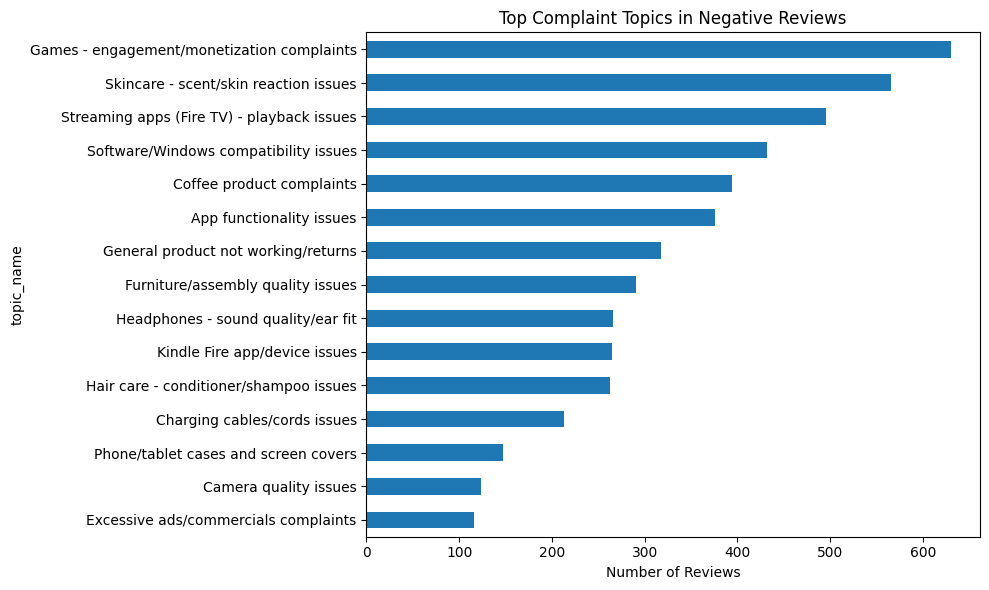

In [9]:
import matplotlib.pyplot as plt

topic_counts = negative_reviews[negative_reviews['topic'] != -1]['topic_name'].value_counts().head(15)

plt.figure(figsize=(10,6))
topic_counts.plot(kind='barh')
plt.xlabel('Number of Reviews')
plt.title('Top Complaint Topics in Negative Reviews')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [10]:
df['review_date'] = pd.to_datetime(df['timestamp'], unit='ms')
df['review_month'] = df['review_date'].dt.to_period('M')
print(df[['timestamp', 'review_date', 'review_month']].head())
print("Date range:", df['review_date'].min(), "to", df['review_date'].max())

       timestamp             review_date review_month
0  1658185117948 2022-07-18 22:58:37.948      2022-07
1  1592678549731 2020-06-20 18:42:29.731      2020-06
2  1523093017534 2018-04-07 09:23:37.534      2018-04
3  1290278495000 2010-11-20 18:41:35.000      2010-11
4  1676601581238 2023-02-17 02:39:41.238      2023-02
Date range: 2000-08-08 07:23:31 to 2023-03-18 02:35:08.237000


In [12]:
df['review_year'] = df['review_date'].dt.year
year_counts = df['review_year'].value_counts().sort_index()
print(year_counts)

review_year
2000        2
2001        5
2002       24
2003       10
2004       33
2005       40
2006       46
2007      112
2008      144
2009      149
2010      247
2011      598
2012     1254
2013     2610
2014     3568
2015     4452
2016     5083
2017     6090
2018     6462
2019     9268
2020    11284
2021    11781
2022     9681
2023     1602
Name: count, dtype: int64


In [13]:
trend_df = df[(df['review_year'] >= 2015) & (df['review_year'] <= 2022)].copy()
print(trend_df.shape)
print(trend_df['review_year'].value_counts().sort_index())

(64101, 12)
review_year
2015     4452
2016     5083
2017     6090
2018     6462
2019     9268
2020    11284
2021    11781
2022     9681
Name: count, dtype: int64


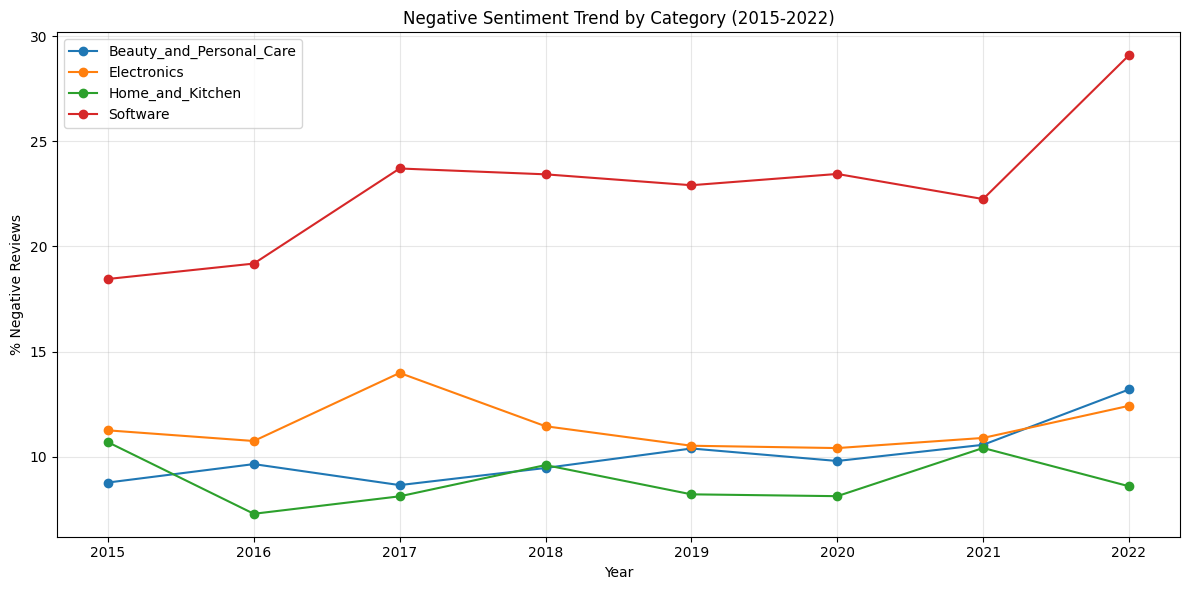

In [14]:
import matplotlib.pyplot as plt

sentiment_trend = trend_df.groupby(['review_year', 'category', 'sentiment']).size().reset_index(name='count')

# Calculate % negative per category per year
totals = trend_df.groupby(['review_year', 'category']).size().reset_index(name='total')
neg_trend = sentiment_trend[sentiment_trend['sentiment'] == 'negative'].merge(totals, on=['review_year', 'category'])
neg_trend['pct_negative'] = (neg_trend['count'] / neg_trend['total']) * 100

plt.figure(figsize=(12,6))
for cat in neg_trend['category'].unique():
    cat_data = neg_trend[neg_trend['category'] == cat]
    plt.plot(cat_data['review_year'], cat_data['pct_negative'], marker='o', label=cat)

plt.xlabel('Year')
plt.ylabel('% Negative Reviews')
plt.title('Negative Sentiment Trend by Category (2015-2022)')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

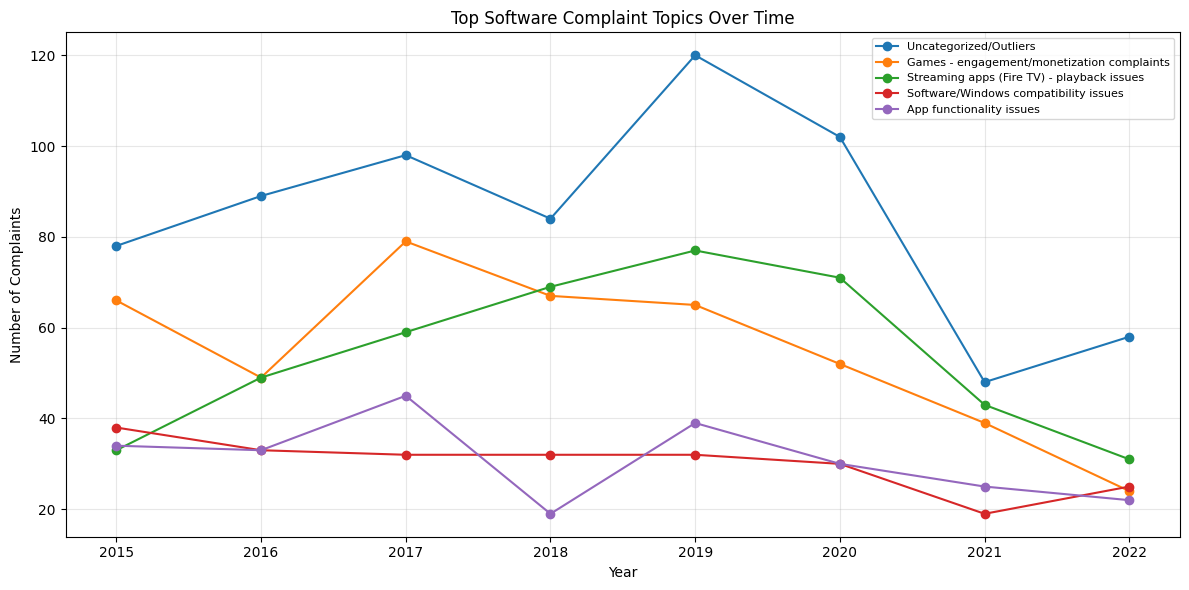

In [15]:
software_negative = negative_reviews[negative_reviews['category'] == 'Software'].copy()
software_negative['review_date'] = pd.to_datetime(
    df.loc[software_negative.index, 'timestamp'], unit='ms'
)
software_negative['review_year'] = software_negative['review_date'].dt.year

software_topic_trend = software_negative[
    (software_negative['review_year'] >= 2015) & (software_negative['review_year'] <= 2022)
].groupby(['review_year', 'topic_name']).size().reset_index(name='count')

top_software_topics = software_negative['topic_name'].value_counts().head(5).index.tolist()
plt.figure(figsize=(12,6))
for topic in top_software_topics:
    t_data = software_topic_trend[software_topic_trend['topic_name'] == topic]
    plt.plot(t_data['review_year'], t_data['count'], marker='o', label=topic)

plt.xlabel('Year')
plt.ylabel('Number of Complaints')
plt.title('Top Software Complaint Topics Over Time')
plt.legend(fontsize=8)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

sentiment           negative   neutral   positive
verified_purchase                                
False               7.062110  9.501986  83.435904
True               15.422009  8.686137  75.891854


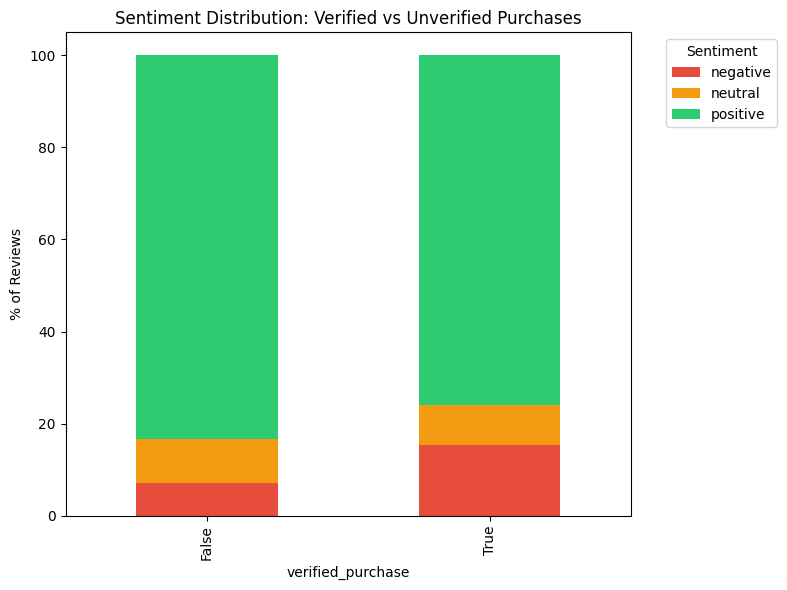

In [16]:
verified_comparison = df.groupby(['verified_purchase', 'sentiment']).size().unstack()
verified_comparison_pct = verified_comparison.div(verified_comparison.sum(axis=1), axis=0) * 100
print(verified_comparison_pct)

verified_comparison_pct.plot(kind='bar', stacked=True, figsize=(8,6), color=['#e74c3c','#f39c12','#2ecc71'])
plt.ylabel('% of Reviews')
plt.title('Sentiment Distribution: Verified vs Unverified Purchases')
plt.legend(title='Sentiment', bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()

In [17]:
import shutil

# Save the trend dataframe for later dashboard use
trend_df.to_parquet("trend_data.parquet", index=False)
shutil.copy("trend_data.parquet", "/content/drive/MyDrive/trend_data.parquet")

negative_reviews.to_parquet("negative_reviews_topics.parquet", index=False)
shutil.copy("negative_reviews_topics.parquet", "/content/drive/MyDrive/negative_reviews_topics.parquet")

print("Saved trend and topic data")

Saved trend and topic data
